In [14]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve

In [15]:
# Step 2: Load dataset
df = pd.read_csv("Assignment1_mimic dataset.csv")

In [16]:
# Step 3: Data preprocessing
# 3.1 Remove irrelevant or leakage variables
X = df.drop(
    labels=["subject_id", "hadm_id", "stay_id", "icu_death_flag", "deathtime", "intime", "outtime"],
    axis=1,
    errors="ignore"
)
y = 1 - df["icu_death_flag"]

# 3.2 Define continuous/categorical variables
cont_cols = [
    'age', 'los', 'sofa2_respiration_24h_max', 'sofa2_cardiovascular_24h_max',
    'heart_rate_min', 'heart_rate_max', 'heart_rate_mean', 'sbp_min', 'sbp_max', 'sbp_mean',
    'dbp_min', 'dbp_max', 'dbp_mean', 'resp_rate_min', 'resp_rate_max', 'resp_rate_mean',
    'temperature_min', 'temperature_max', 'temperature_mean', 'spo2_min', 'spo2_max', 'spo2_mean',
    'glucose_min', 'glucose_max', 'glucose_mean', 'hematocrit_min', 'hematocrit_max',
    'hemoglobin_min', 'hemoglobin_max', 'platelets_min', 'platelets_max', 'wbc_min', 'wbc_max',
    'creatinine_min', 'creatinine_max', 'sodium_min', 'sodium_max', 'potassium_min', 'potassium_max'
]

cat_cols = [
    'first_careunit', 'last_careunit', 'insurance', 'language', 'race',
    'marital_status', 'gender', 'gcs_motor', 'gcs_verbal', 'gcs_eyes', 'gcs_unable'
]

# 3.3 Execute preprocessing and split dataset
preprocessor = ColumnTransformer(
    transformers=[
        ("cont", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), cont_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop"
)
X_processed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, stratify=y
)

In [17]:
# Step 4: Feature selection (L1/Lasso)
lasso = Lasso(alpha=0.01, max_iter=2000)
lasso.fit(X_train, y_train)
sfm = SelectFromModel(lasso, threshold="mean", prefit=True)
X_train_selected = sfm.transform(X_train)
X_test_selected = sfm.transform(X_test)
print("Feature Selection Results:")
print(f"Original dimension: {X_train.shape[1]}")
print(f"Dimension after selection: {X_train_selected.shape[1]}")

Feature Selection Results:
Original dimension: 158
Dimension after selection: 17


In [23]:
# Step 5: Model training and evaluation
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced")
}
model_results = {}
y_proba = {}
for name, model in models.items():
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    y_pred_proba = model.predict_proba(X_test_selected)[:, 1]
    
# Calculate core metrics
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
    auroc = roc_auc_score(y_test, y_pred_proba)
    model_results[name] = [acc, prec, rec, f1, auroc]
    y_proba[name] = y_pred_proba
print("\nModel Performance Results:")
print(f"{'Model':<22} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1 Score':<10} {'AUROC':<10}")
print("-" * 80)
for name, res in model_results.items():
    print(f"{name:<22} {res[0]:<10.3f} {res[1]:<10.3f} {res[2]:<10.3f} {res[3]:<10.3f} {res[4]:<10.3f}")


Model Performance Results:
Model                  Accuracy   Precision  Recall     F1 Score   AUROC     
--------------------------------------------------------------------------------
Logistic Regression    0.827      0.977      0.831      0.898      0.891     
Decision Tree          0.923      0.933      0.987      0.959      0.841     
Random Forest          0.933      0.936      0.995      0.964      0.914     


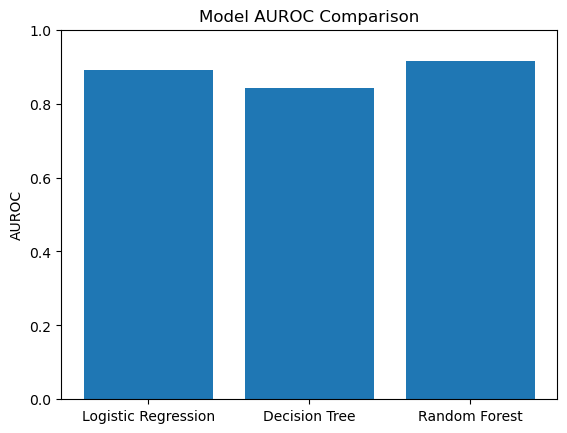

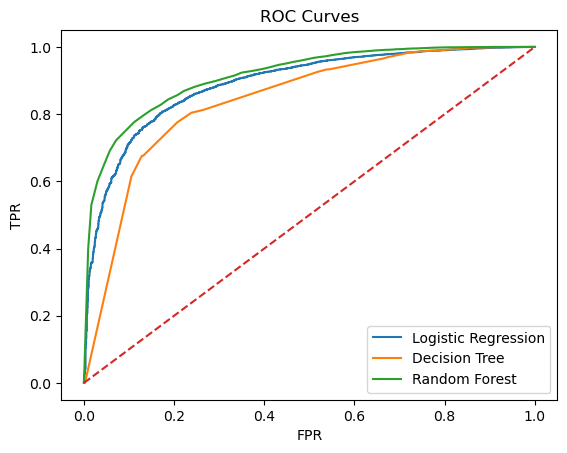

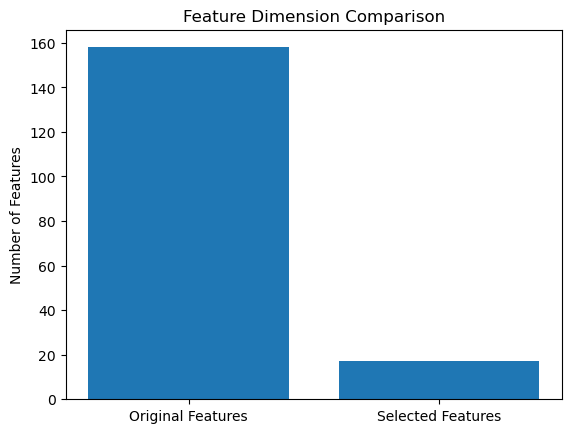

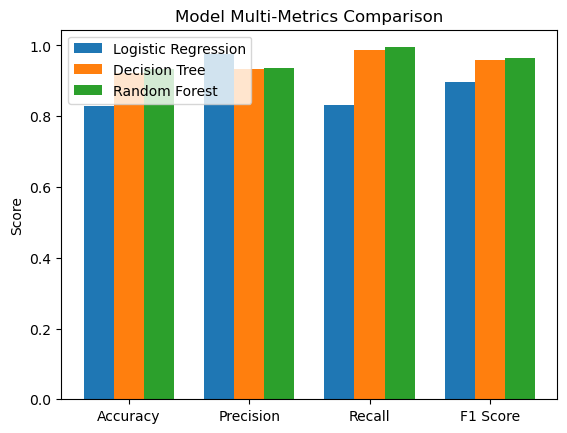

In [24]:
# Step 6: Visualization
# 6.1 AUROC comparison chart
model_names = list(model_results.keys())
aurocs = [res[4] for res in model_results.values()]
plt.figure()
plt.bar(model_names,aurocs)
plt.title("Model AUROC Comparison")
plt.ylabel("AUROC")
plt.ylim(0, 1)
plt.show()

# 6.2 ROC curves
plt.figure()
for name, prob in y_proba.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

# 6.3 Feature dimension comparison chart
plt.figure()
plt.bar(["Original Features", "Selected Features"], [X_train.shape[1], X_train_selected.shape[1]])
plt.title("Feature Dimension Comparison")
plt.ylabel("Number of Features")
plt.show()

# 6.4 Model multi-metrics comparison chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_metrics = model_results["Logistic Regression"][:4]
dt_metrics = model_results["Decision Tree"][:4]
rf_metrics = model_results["Random Forest"][:4]

x = np.arange(len(metrics))
width = 0.25
plt.figure()
plt.bar(x - width, lr_metrics, width, label='Logistic Regression')
plt.bar(x, dt_metrics, width, label='Decision Tree')
plt.bar(x + width, rf_metrics, width, label='Random Forest')

plt.title("Model Multi-Metrics Comparison")
plt.ylabel("Score")
plt.xticks(x, metrics)
plt.legend()
plt.show()

In [25]:
# Step 7: Result summary
best_model = model_names[aurocs.index(max(aurocs))]
print(f"\nBest model: {best_model}, AUROC: {max(aurocs):.3f}")
print(f"Feature dimension reduced from {X_train.shape[1]} to {X_train_selected.shape[1]} after selection, effective dimensionality reduction")


Best model: Random Forest, AUROC: 0.914
Feature dimension reduced from 158 to 17 after selection, effective dimensionality reduction
